# Corporate AI Disclosure EDA — 42-company expansion

Exploratory, purposive stratified sample of annual SEC primary Form 10-K documents, selected at the fixed **October 8, 2026** cutoff. All semantic coding is AI-first and **not human-validated**. This notebook separates lexical attention, strategic intent, reported implementation, and risks/governance. No enterprise maturity index, adoption truth, extraction recall, or causal effects are estimated.

Run all cells from the project root with the project virtual environment. Relative data paths are the default; `DIAL_DATA_DIR` supports testing staged replacements. Protocol.md remains the conceptual baseline.

In [1]:
from pathlib import Path
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'Protocol.md').exists():
    raise RuntimeError('Run this notebook with the project root as working directory.')
DATA = Path(os.environ.get('DIAL_DATA_DIR', 'data'))
sources = pd.read_csv(DATA / 'sources_downloaded.csv', keep_default_na=False)
passages = pd.read_csv(DATA / 'ai_passages.csv', keep_default_na=False)
full = pd.read_csv(DATA / 'ai_annotations_full.csv', keep_default_na=False)
core = pd.read_csv(DATA / 'ai_annotations.csv', keep_default_na=False,
                   dtype={'adoption_stage':str, 'strategy_specificity':str})
metrics = pd.read_csv(DATA / 'document_metrics.csv', keep_default_na=False)
assert sources.ticker.is_unique and metrics.ticker.is_unique
assert set(sources.ticker) == set(metrics.ticker)
assert set(passages.passage_id) == set(full.passage_id)
assert set(core.claim_id) == set(full.loc[full.adoption_stage != 'NA', 'claim_id'])
assert (full.human_validated == 'no').all()
sectors = sources.sector.drop_duplicates().tolist()
short = {s:s.split(' / ')[0] for s in sectors}
palette = dict(zip(sectors, plt.get_cmap('tab10').colors[:len(sectors)]))
plt.rcParams.update({'figure.dpi':110, 'font.size':10, 'axes.spines.top':False, 'axes.spines.right':False})
def firm_plot(column, title, xlabel):
    plot_df = metrics.sort_values(column)
    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df)*.24)))
    ax.barh(plot_df.ticker, plot_df[column], color=plot_df.sector.map(palette))
    ax.set(title=title, xlabel=xlabel, ylabel='Selected issuer'); ax.grid(axis='x', alpha=.2)
    fig.tight_layout(); plt.show()
def sector_box(column, title, ylabel):
    groups = [metrics.loc[metrics.sector == s, column].to_numpy() for s in sectors]
    fig, ax = plt.subplots(figsize=(10,4.5))
    ax.boxplot(groups, tick_labels=[short[s] for s in sectors], showfliers=False)
    for i,(s,g) in enumerate(zip(sectors,groups),1):
        # Fixed offsets make plots reproducible; each dot is one company.
        ax.scatter(i + np.linspace(-.15,.15,len(g)), g, color=palette[s], s=40, alpha=.8)
    ax.set(title=title, ylabel=ylabel); ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=.2); fig.tight_layout(); plt.show()
display(Markdown(f'Execution interpreter: `{sys.executable}`. Companies: **{len(metrics)}**.'))

Execution interpreter: `C:\Users\KPdesktop\Desktop\DIAL-AI-adoption\.venv\Scripts\python.exe`. Companies: **42**.

## 1 — Dataset overview

A candidate is a keyword-matching paragraph block, with meaningful original context. An archival record is a separately interpretable claim or screening decision; one candidate can produce several records. The core table includes only substantive focal-firm claims with defensible Stages 1–5. NA is an eligibility/measurement outcome, never Stage 0 or evidence of nonadoption. Resolved application IDs group repeated disclosures within the same firm/period.

In [2]:
focal = full[(full.ai_relevance == 'substantive') & (full.actor == 'focal_firm') & (full.focal_firm_evidence == 'yes')]
all_cases = focal.loc[(focal.use_case_identity_status == 'resolved') & (focal.use_case_id != 'NA'), 'use_case_id'].nunique()
overview = pd.Series({'Selected companies':len(sources), 'Sectors':sources.sector.nunique(),
    'Subsectors':sources.subsector.nunique(), 'Annual filings':len(sources),
    'Candidate passages':len(passages), 'Full claim/screening records':len(full),
    'Stage-eligible core claims':len(core), 'Stage NA records':(full.adoption_stage == 'NA').sum(),
    'Resolved applications (all disclosed statuses)':all_cases,
    'Resolved current deployed applications':metrics.deployed_use_case_count.sum()}, name='Count')
display(overview.to_frame())
display(sources.groupby(['sector','subsector']).size().rename('Companies').to_frame())
display(sources[['ticker','sector','period_end','filing_date','source_scope_note']])
display(metrics.select_dtypes('number').describe().T)
display(metrics.dtypes.to_frame(name='dtype'))

,Count
Selected companies,42
Sectors,6
Subsectors,19
Annual filings,42
Candidate passages,770
Full claim/screening records,844
Stage-eligible core claims,276
Stage NA records,568
Resolved applications (all disclosed statuses),109
Resolved current deployed applications,98


Companies
sector                       subsector                                        
Energy / Oil & Gas           Downstream / refining                           1
                             Integrated oil and gas                          2
                             Oilfield services / technology                  1
                             Upstream oil and gas                            3
Financial Services / Banking Diversified / commercial banking                5
                             Investment banking / wealth management          2
Healthcare / Pharmaceuticals Pharmaceuticals / biotechnology                 7
Industrials / Manufacturing  Aerospace / defense                             1
                             Aerospace engines / services                    1
                             Agricultural machinery                          1
                             Construction / mining machinery                 1
                             Diversified industrial technology               1
                             Diversified manufacturing                       1
                             Power management                                1
Retail / Consumer Commerce   Commerce / cloud infrastructure                 1
                             General / grocery retail                        4
                             Home improvement retail                         2
Technology / Software        Internet platforms                              2
                             Software / cloud                                5

,ticker,sector,period_end,filing_date,source_scope_note
0,MSFT,Technology / Software,2026-06-30,2026-07-29,Complete primary 10-K; exhibits and proxy mate...
1,ADBE,Technology / Software,2025-11-28,2026-01-15,Complete primary 10-K; exhibits and proxy mate...
2,CRM,Technology / Software,2026-01-31,2026-03-02,Complete primary 10-K; exhibits and proxy mate...
3,GOOGL,Technology / Software,2025-12-31,2026-02-05,Complete primary 10-K; exhibits and proxy mate...
4,META,Technology / Software,2025-12-31,2026-01-29,Complete primary 10-K; exhibits and proxy mate...
5,ORCL,Technology / Software,2026-05-31,2026-06-22,Complete primary 10-K; exhibits and proxy mate...
6,NOW,Technology / Software,2025-12-31,2026-01-29,Complete primary 10-K; exhibits and proxy mate...
7,WMT,Retail / Consumer Commerce,2026-01-31,2026-03-13,Complete primary 10-K; exhibits and proxy mate...
8,TGT,Retail / Consumer Commerce,2026-01-31,2026-03-11,Complete primary 10-K; exhibits and proxy mate...
9,COST,Retail / Consumer Commerce,2026-08-30,2026-10-07,Complete primary 10-K; exhibits and proxy mate...


,count,mean,std,min,25%,50%,75%,max
total_word_count,42.0,70578.880952,36784.967510,13485.000000,50775.500000,62523.000000,78782.500000,177460.000000
ai_candidate_passage_count,42.0,18.333333,24.543308,1.000000,3.250000,8.500000,19.750000,101.000000
ai_candidate_word_count,42.0,2470.380952,3118.162083,18.000000,466.250000,1168.500000,3293.500000,12998.000000
ai_candidate_word_share,42.0,0.041383,0.055822,0.001335,0.007727,0.016203,0.046859,0.258466
ai_mention_count,42.0,38.904762,50.953738,1.000000,7.750000,15.500000,40.250000,175.000000
ai_mentions_per_1000_words,42.0,0.650621,0.948610,0.013213,0.101562,0.273247,0.458901,3.660399
substantive_ai_claim_count,42.0,19.071429,26.125768,0.000000,4.000000,9.000000,20.000000,110.000000
strategy_claim_count,42.0,2.214286,4.033613,0.000000,0.000000,1.000000,2.000000,23.000000
stage_eligible_claim_count,42.0,6.571429,10.590246,0.000000,1.000000,2.000000,5.750000,37.000000
stage_na_claim_count,42.0,13.523810,17.694202,0.000000,2.000000,6.000000,19.000000,85.000000


,dtype
ticker,str
source_file,str
total_word_count,int64
ai_candidate_passage_count,int64
ai_candidate_word_count,int64
ai_candidate_word_share,float64
ai_mention_count,int64
ai_mentions_per_1000_words,float64
sector,str
subsector,str


**Source scope matters.** Complete primary 10-K files were obtained for every selected issuer. WFC and USB incorporate substantial annual-report sections by reference; those separate documents are outside the uniform primary-document extraction. Their low densities and observed zeros should receive a scope sensitivity check. Fiscal year ends differ, so this is a cutoff-based snapshot rather than identical observation periods. Amazon combines commerce with AWS; GE retains the same SEC issuer after business separation. XOM uses its documented predecessor annual filing.

## 2 — Disclosure intensity

Nonoverlapping lexical matches divided by all primary-document whitespace words, ×1,000. These are attention measures, including risks and potential false matches. Each sector box/strip plot weights its seven firms equally. The retained candidate-share scatter describes retrieval coverage; its word share includes non-AI paragraph context and is **not substantive AI topic share**.

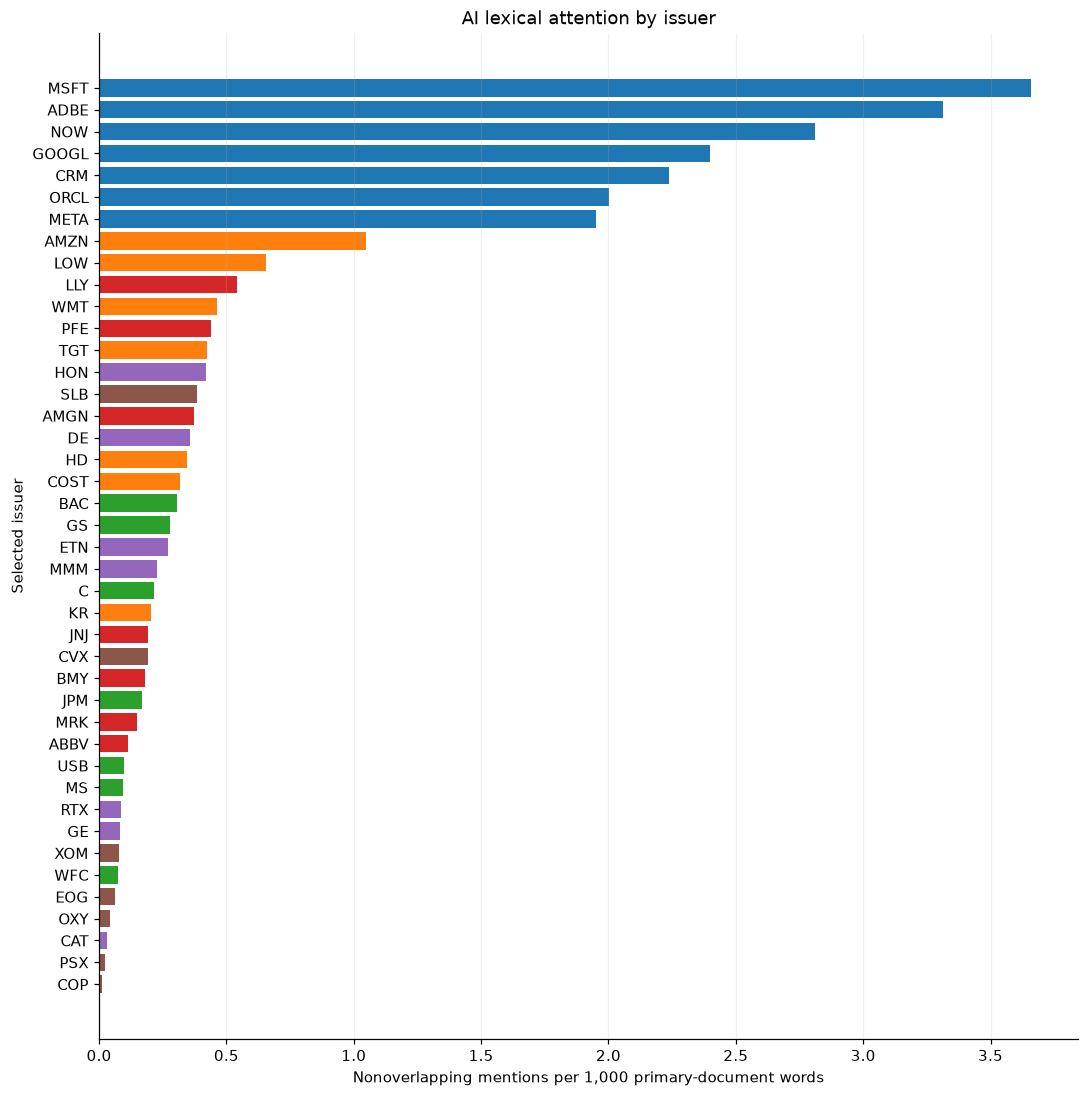

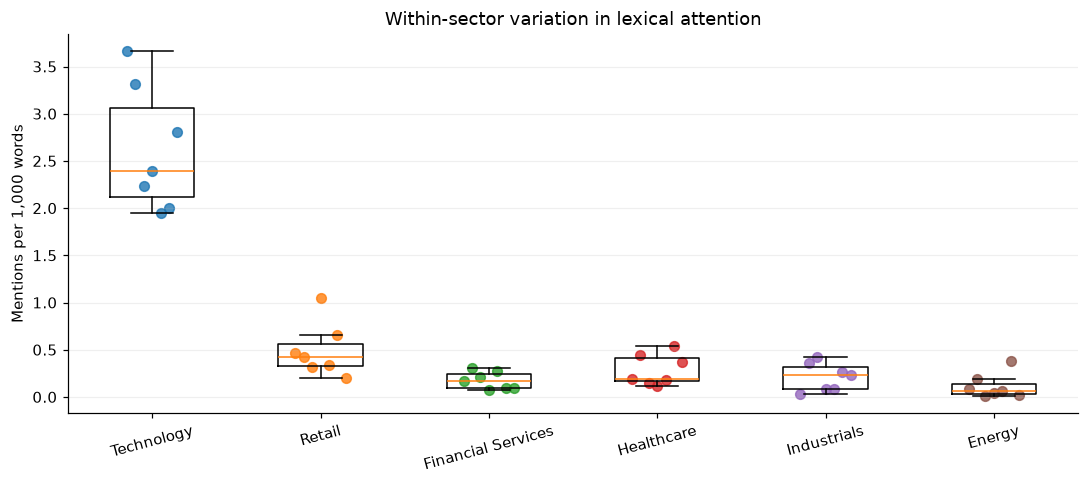

In [3]:
firm_plot('ai_mentions_per_1000_words', 'AI lexical attention by issuer', 'Nonoverlapping mentions per 1,000 primary-document words')
sector_box('ai_mentions_per_1000_words', 'Within-sector variation in lexical attention', 'Mentions per 1,000 words')

,count,mean,median,min,max
sector,,,,,
Energy / Oil & Gas,7,0.113920,0.062174,0.013213,0.382544
Financial Services / Banking,7,0.176639,0.169458,0.074156,0.307861
Healthcare / Pharmaceuticals,7,0.283925,0.191880,0.111987,0.540057
Industrials / Manufacturing,7,0.210955,0.228141,0.030388,0.419715
Retail / Consumer Commerce,7,0.493465,0.422404,0.203772,1.046647
Technology / Software,7,2.624825,2.397438,1.951640,3.660399


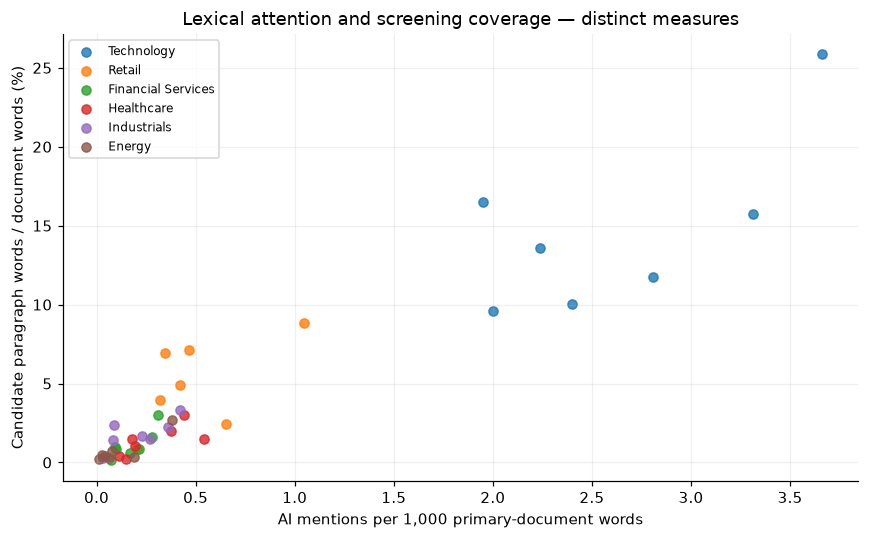

In [4]:
display(metrics.groupby('sector').ai_mentions_per_1000_words.agg(['count','mean','median','min','max']))
fig, ax = plt.subplots(figsize=(8,5))
for sector,g in metrics.groupby('sector',sort=False):
    ax.scatter(g.ai_mentions_per_1000_words, 100*g.ai_candidate_word_share, label=short[sector], color=palette[sector], alpha=.8)
ax.set(xlabel='AI mentions per 1,000 primary-document words', ylabel='Candidate paragraph words / document words (%)',
       title='Lexical attention and screening coverage — distinct measures')
ax.legend(fontsize=8); ax.grid(alpha=.2); fig.tight_layout(); plt.show()

## 3 — Strategy and adoption evidence

The core denominator is eligible claims, conditional on passing stage eligibility. Stages summarize evidence statements rather than whole firms. Stage 5 requires an attributable realized numerical outcome and maps to operational Stage 4 for deployment counts; no Stage 5 claim was supported here. A provider’s deployed product is kept distinct from its internal operations and customer-adoption statements.

,Eligible claims
adoption_stage,
1,79
2,15
3,1
4,181
5,0


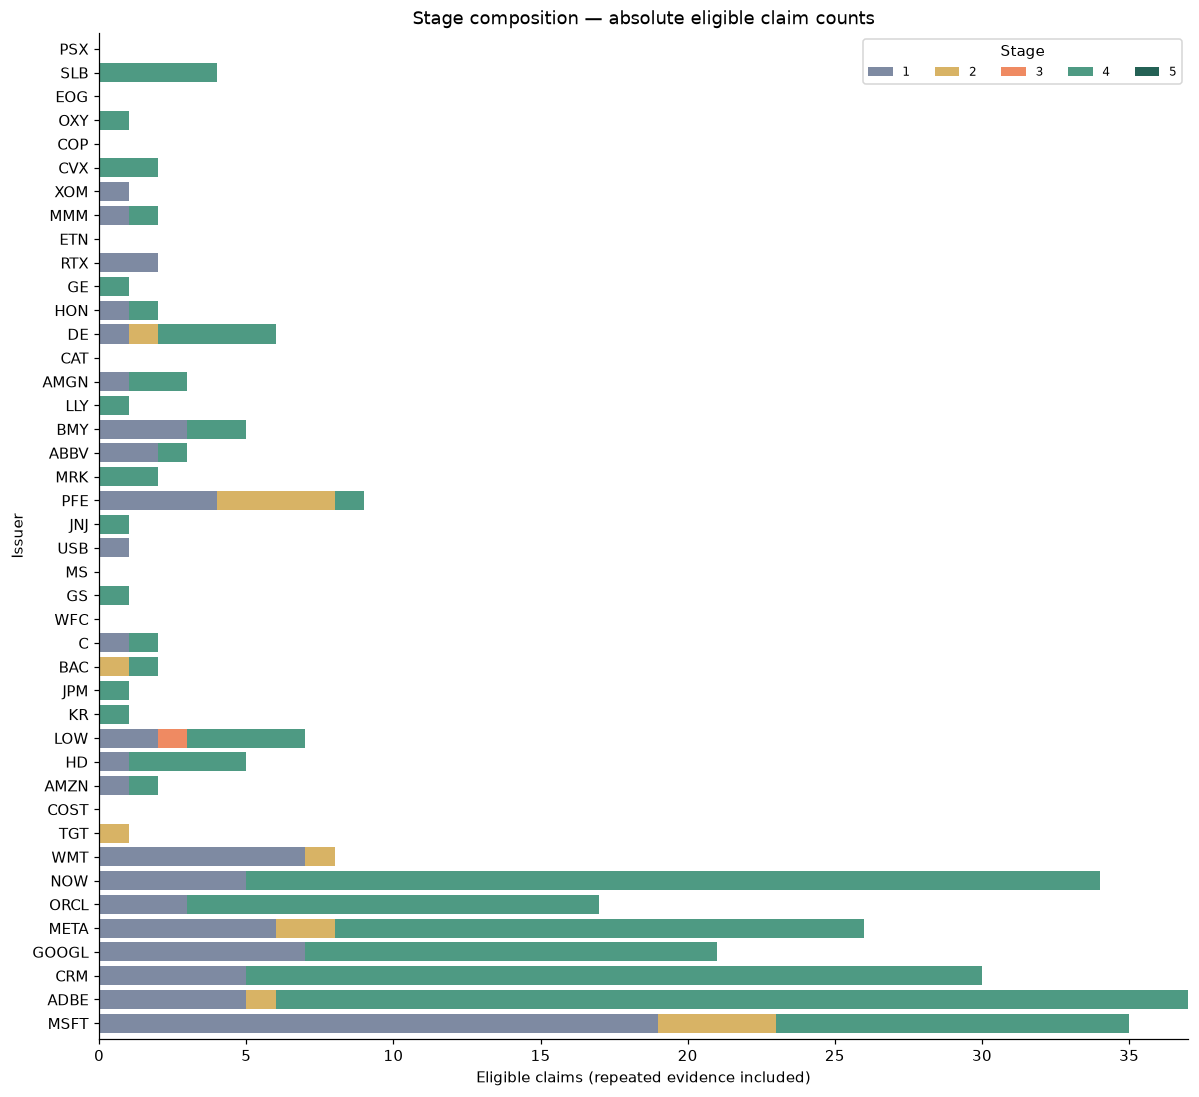

In [5]:
stage_order = ['1','2','3','4','5']
stage_counts = core.adoption_stage.value_counts().reindex(stage_order,fill_value=0)
assert int(stage_counts.sum()) == len(core)
assert stage_counts.to_dict() == full.loc[full.adoption_stage != 'NA','adoption_stage'].value_counts().reindex(stage_order,fill_value=0).to_dict()
display(stage_counts.rename('Eligible claims').to_frame())
composition = pd.crosstab(core.ticker, core.adoption_stage).reindex(index=sources.ticker,columns=stage_order,fill_value=0).fillna(0)
assert int(composition.to_numpy().sum()) == len(core)
fig, ax = plt.subplots(figsize=(11, max(7,len(sources)*.24)))
composition.plot.barh(stacked=True,ax=ax,color=['#7e8aa2','#d8b365','#ef8a62','#4e9a83','#246155'],width=.8)
ax.set(title='Stage composition — absolute eligible claim counts',xlabel='Eligible claims (repeated evidence included)',ylabel='Issuer')
ax.legend(title='Stage',ncol=5,fontsize=8); fig.tight_layout(); plt.show()

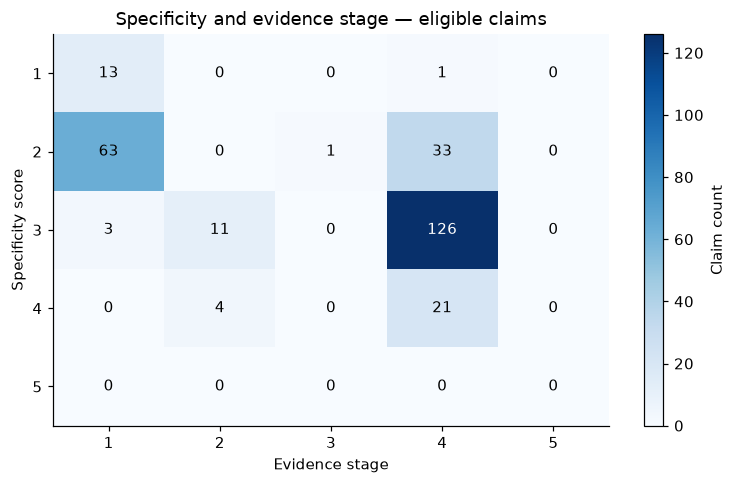

,Firms with strategy label
label,
efficiency,14
innovation,11
customer_experience,10
workforce_productivity,10
competitive_positioning,7
responsible_ai,6
revenue_growth,3
security,2
infrastructure_capacity,1


,Mean explicit-strategy specificity; missing means no coded strategy
ticker,
MSFT,1.956522
ADBE,2.000000
CRM,2.000000
GOOGL,1.714286
META,2.000000
ORCL,2.000000
NOW,1.800000
WMT,2.125000
TGT,3.000000


In [6]:
specificity = core.assign(specificity=pd.to_numeric(core.strategy_specificity,errors='coerce'))
cross = pd.crosstab(specificity.specificity, specificity.adoption_stage).reindex(index=range(1,6),columns=stage_order,fill_value=0).fillna(0)
assert int(cross.to_numpy().sum()) == len(core)
fig, ax = plt.subplots(figsize=(7,4.5)); im=ax.imshow(cross.to_numpy(),cmap='Blues',aspect='auto')
ax.set(xticks=range(5),xticklabels=stage_order,yticks=range(5),yticklabels=range(1,6),xlabel='Evidence stage',ylabel='Specificity score',title='Specificity and evidence stage — eligible claims')
for y in range(5):
    for x in range(5):ax.text(x,y,str(int(cross.iloc[y,x])),ha='center',va='center',color='white' if cross.iloc[y,x]>cross.to_numpy().max()/2 else 'black')
fig.colorbar(im,ax=ax,label='Claim count'); fig.tight_layout(); plt.show()
strategic = focal[focal.is_strategy_claim == 'yes']
orientation = strategic[['ticker','strategic_orientation']].assign(label=lambda d:d.strategic_orientation.str.split('|')).explode('label')
orientation = orientation[orientation.label != 'NA'].drop_duplicates(['ticker','label'])
display(orientation.groupby('label').ticker.nunique().sort_values(ascending=False).rename('Firms with strategy label').to_frame())
display(strategic.groupby('ticker').strategy_specificity.apply(lambda v:pd.to_numeric(v,errors='coerce').mean()).reindex(sources.ticker).rename('Mean explicit-strategy specificity; missing means no coded strategy').to_frame())

,Count
Resolved intended application IDs,11
Resolved current deployed IDs,98
IDs with both planned and current evidence,2
Pilot claims (includes unresolved tasks),1
Current deployment claims with unresolved task identity,39


,ticker,distinct_ai_use_case_count,deployed_use_case_count,internal_deployed_use_case_count,customer_facing_deployed_use_case_count,reported_deployment_present
0,MSFT,10,8,1,6,1
1,ADBE,13,13,0,13,1
2,CRM,17,17,1,16,1
3,GOOGL,11,11,0,9,1
4,META,7,6,2,4,1
5,ORCL,6,6,0,5,1
6,NOW,22,22,1,21,1
7,WMT,1,0,0,0,0
8,TGT,2,0,0,0,0
9,COST,0,0,0,0,0


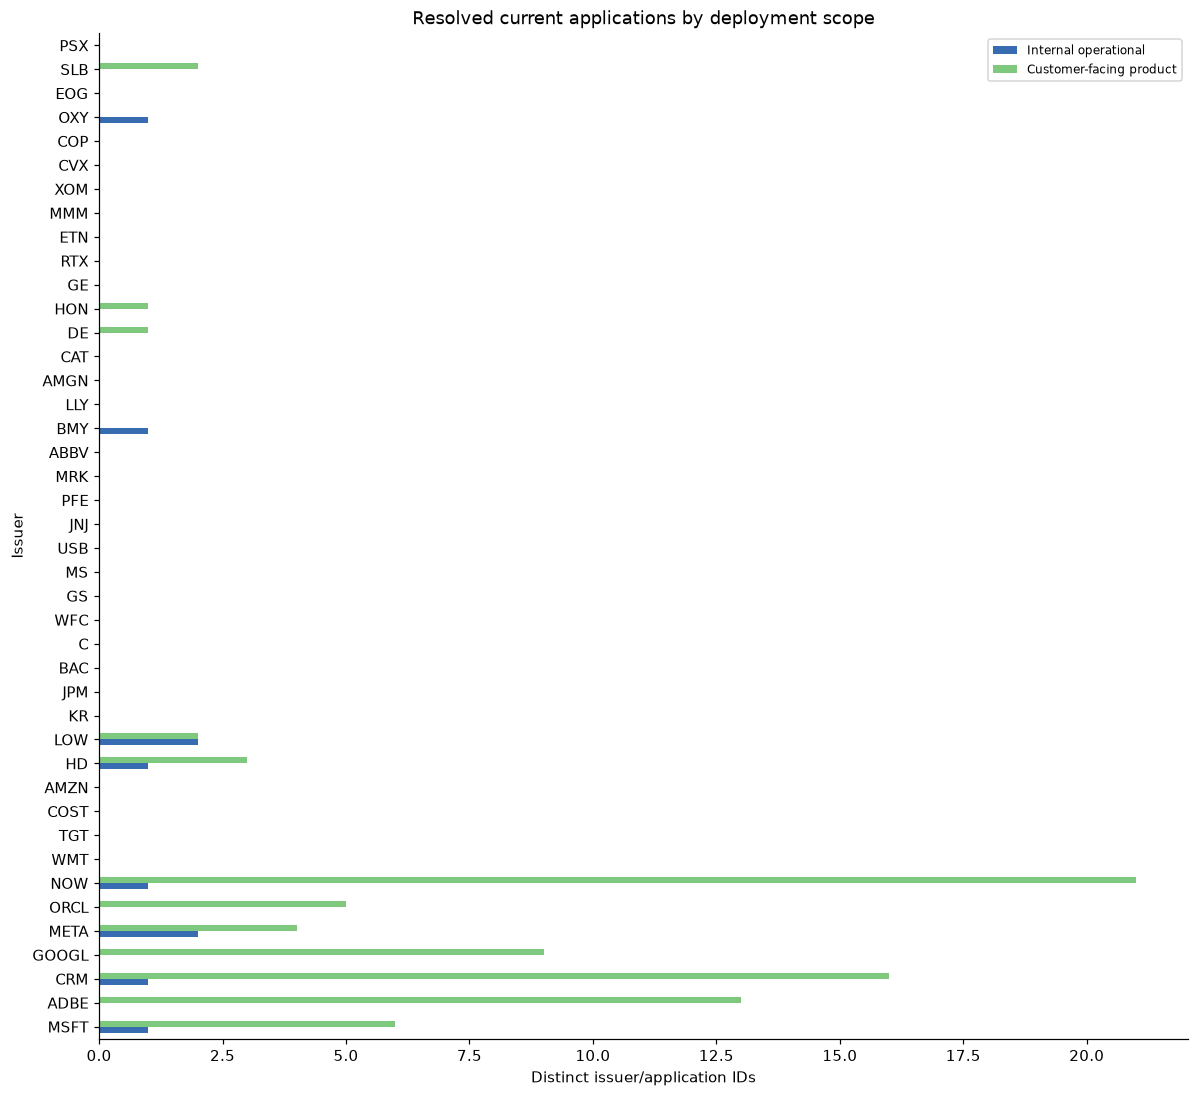

In [7]:
resolved = focal[(focal.use_case_id != 'NA') & (focal.use_case_identity_status == 'resolved')]
current_ids = set(resolved.loc[(resolved.adoption_stage.isin(['4','5'])) & (resolved.temporal_status == 'current'),'use_case_id'])
planned_ids = set(resolved.loc[resolved.adoption_stage == '2','use_case_id'])
display(pd.Series({'Resolved intended application IDs':len(planned_ids),
    'Resolved current deployed IDs':len(current_ids), 'IDs with both planned and current evidence':len(current_ids & planned_ids),
    'Pilot claims (includes unresolved tasks)':(core.adoption_stage == '3').sum(),
    'Current deployment claims with unresolved task identity':((core.adoption_stage.isin(['4','5'])) & (core.use_case_id == 'NA')).sum()},name='Count').to_frame())
display(metrics[['ticker','distinct_ai_use_case_count','deployed_use_case_count','internal_deployed_use_case_count','customer_facing_deployed_use_case_count','reported_deployment_present']])
scoped = metrics.set_index('ticker')[['internal_deployed_use_case_count','customer_facing_deployed_use_case_count']]
fig,ax=plt.subplots(figsize=(11, max(7,len(scoped)*.24)))
scoped.plot.barh(ax=ax,color=['#386cb0','#7fc97f']); ax.set(title='Resolved current applications by deployment scope',xlabel='Distinct issuer/application IDs',ylabel='Issuer')
ax.legend(['Internal operational','Customer-facing product'],fontsize=8); fig.tight_layout(); plt.show()

Application counts include only explicitly resolved task identities. Broad current-use claims can establish deployment presence while yielding zero resolved application IDs. Scope flags may overlap in other datasets; internal/product counts must not automatically be summed. R&D and infrastructure applications are outside those two scope counts. Products with multiple models or repeated marketing surfaces are grouped by disclosed task, not counted per model, mention, or claim.

## 4 — Cross-sector comparisons

Default unit: one issuer/selected filing. Sector means and proportions include all selected firms, including zero observed qualifying claims. Mean claim counts are supplemental descriptions of communication; normalized counts below use primary-document words. Neither is an adoption prevalence estimate. No statistical significance tests are claimed.

,companies,mean_mentions_per_1000,median_mentions_per_1000,strategy_firm_share,deployment_evidence_firm_share,mean_resolved_deployments,risk_firm_share,governance_firm_share,mean_eligible_claims_per_10000_words
sector,,,,,,,,,
Energy / Oil & Gas,7,0.113920,0.062174,0.285714,0.428571,0.428571,1.000000,0.285714,0.251023
Financial Services / Banking,7,0.176639,0.169458,0.428571,0.571429,0.000000,0.714286,0.714286,0.124306
Healthcare / Pharmaceuticals,7,0.283925,0.191880,0.571429,1.000000,0.285714,1.000000,0.142857,0.419202
Industrials / Manufacturing,7,0.210955,0.228141,0.571429,0.571429,0.285714,0.857143,0.000000,0.296721
Retail / Consumer Commerce,7,0.493465,0.422404,0.714286,0.571429,1.142857,1.000000,0.285714,0.717254
Technology / Software,7,2.624825,2.397438,1.000000,1.000000,11.857143,1.000000,0.857143,5.175149


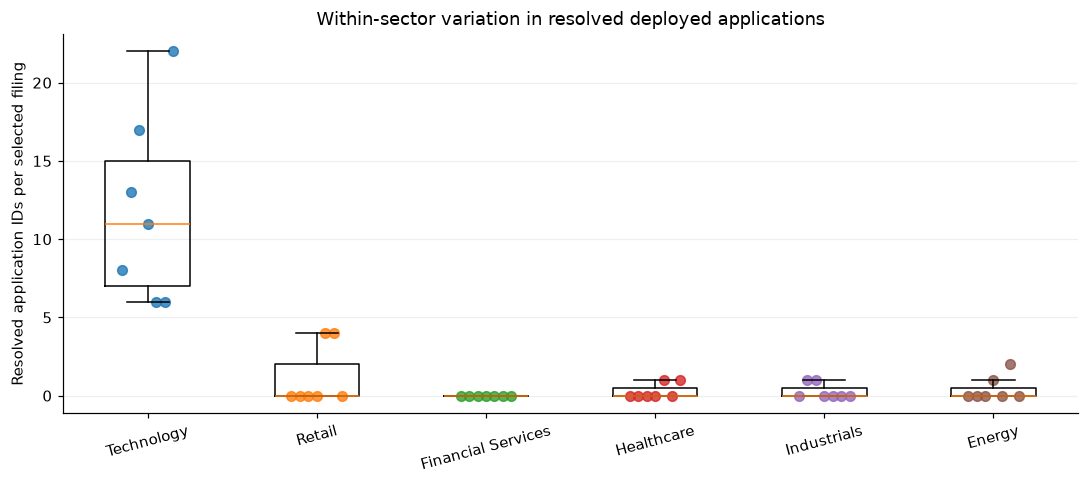

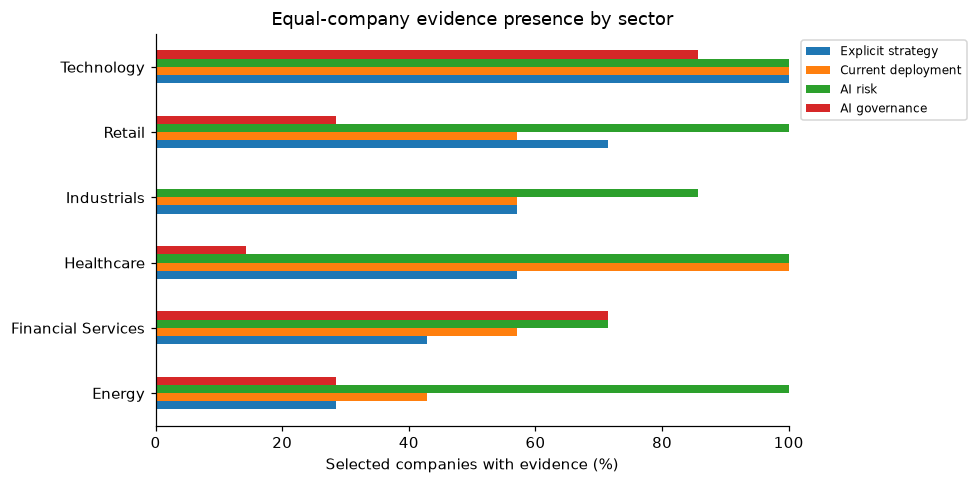

In [8]:
company = metrics.copy()
company['explicit_strategy_present'] = (company.strategy_claim_count > 0).astype(int)
company['risk_present'] = (company.ai_risk_claim_count > 0).astype(int)
company['governance_present'] = (company.ai_governance_claim_count > 0).astype(int)
company['eligible_claims_per_10000_words'] = company.stage_eligible_claim_count*10000/company.total_word_count
sector_summary = company.groupby('sector').agg(
    companies=('ticker','size'),mean_mentions_per_1000=('ai_mentions_per_1000_words','mean'),
    median_mentions_per_1000=('ai_mentions_per_1000_words','median'),
    strategy_firm_share=('explicit_strategy_present','mean'),deployment_evidence_firm_share=('reported_deployment_present','mean'),
    mean_resolved_deployments=('deployed_use_case_count','mean'),risk_firm_share=('risk_present','mean'),governance_firm_share=('governance_present','mean'),
    mean_eligible_claims_per_10000_words=('eligible_claims_per_10000_words','mean'))
display(sector_summary)
sector_box('deployed_use_case_count','Within-sector variation in resolved deployed applications','Resolved application IDs per selected filing')
fig,ax=plt.subplots(figsize=(9,4.5))
shares=sector_summary[['strategy_firm_share','deployment_evidence_firm_share','risk_firm_share','governance_firm_share']].copy()
shares.index=[short[s] for s in shares.index]
(shares*100).plot.barh(ax=ax); ax.set(xlabel='Selected companies with evidence (%)',title='Equal-company evidence presence by sector',xlim=(0,100))
ax.legend(['Explicit strategy','Current deployment','AI risk','AI governance'],fontsize=8,bbox_to_anchor=(1.01,1));fig.tight_layout();plt.show()

In [9]:
sensitivity = company[~company.ticker.isin(['WFC','USB'])].groupby('sector').agg(companies=('ticker','size'),mean_density=('ai_mentions_per_1000_words','mean'),deployment_firm_share=('reported_deployment_present','mean'))
display(sensitivity.rename(columns={'mean_density':'Sensitivity: mean density excluding incorporated-report banks'}))
display(Markdown('This sensitivity table changes the financial-sector denominator to five; it does not repair missing incorporated text or replace the seven-company primary comparison.'))

,companies,Sensitivity: mean density excluding incorporated-report banks,deployment_firm_share
sector,,,
Energy / Oil & Gas,7,0.113920,0.428571
Financial Services / Banking,5,0.212846,0.800000
Healthcare / Pharmaceuticals,7,0.283925,1.000000
Industrials / Manufacturing,7,0.210955,0.571429
Retail / Consumer Commerce,7,0.493465,0.571429
Technology / Software,7,2.624825,1.000000


This sensitivity table changes the financial-sector denominator to five; it does not repair missing incorporated text or replace the seven-company primary comparison.

## 5 — Methodological diagnostics

NA rates use **all archival records per firm**; parent eligibility uses **candidate passages with at least one eligible claim / all candidate passages**. Neither is a percentage of AI words or firm adoption. `stage_na_reason` is a transparent, priority-based grouping of existing labels, not independently validated causal diagnosis. Review flags prioritize cases; unflagged rows remain human-unvalidated.

,full_records,na_records,review_records,na_rate,eligible_candidate_share
ticker,,,,,
MSFT,120,85,27,0.708333,0.306931
ADBE,73,36,17,0.493151,0.484375
CRM,81,51,10,0.629630,0.333333
GOOGL,57,36,1,0.631579,0.345455
META,79,53,6,0.670886,0.293333
ORCL,44,27,11,0.613636,0.372093
NOW,72,38,6,0.527778,0.478261
WMT,22,14,4,0.636364,0.421053
TGT,12,11,3,0.916667,0.100000


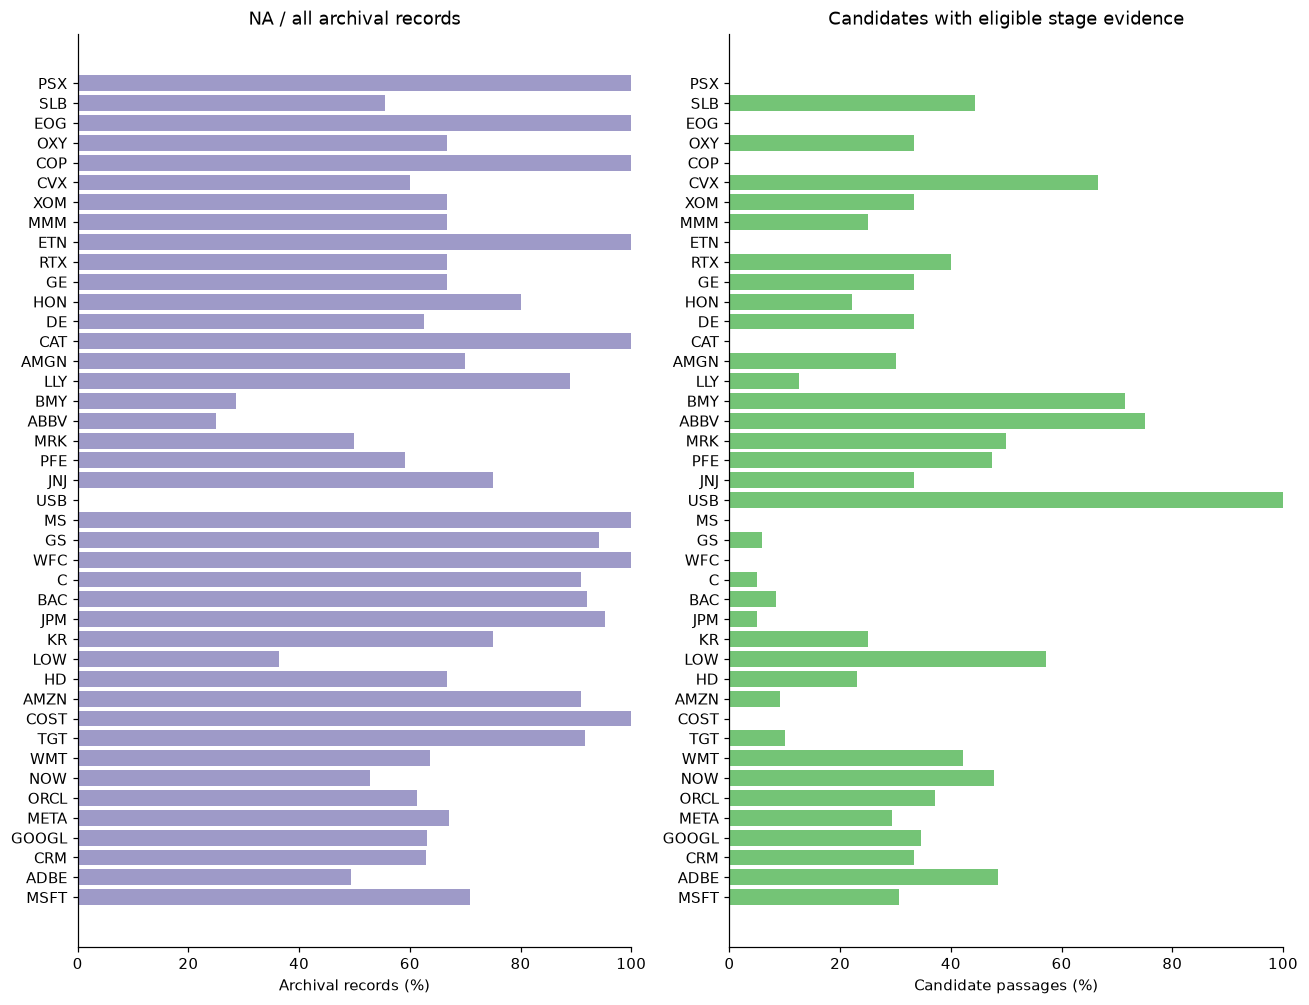

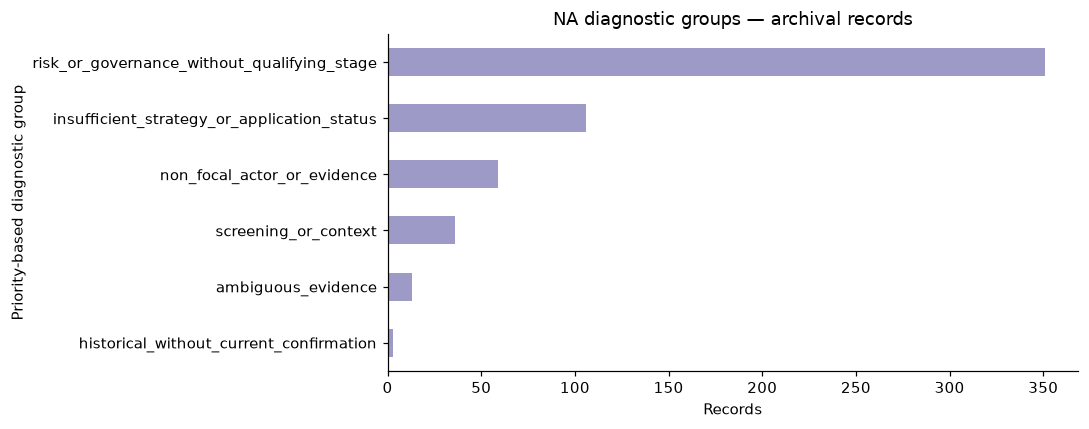

In [10]:
diagnostics=full.groupby('ticker').agg(full_records=('claim_id','size'),na_records=('adoption_stage',lambda s:(s == 'NA').sum()),review_records=('needs_human_review',lambda s:(s == 'yes').sum()))
diagnostics=diagnostics.reindex(sources.ticker).fillna(0)
diagnostics['na_rate']=diagnostics.na_records/diagnostics.full_records.replace(0,np.nan)
parent_total=passages.groupby('ticker').passage_id.nunique().reindex(sources.ticker,fill_value=0)
parent_eligible=core.groupby('ticker').passage_id.nunique().reindex(sources.ticker,fill_value=0)
diagnostics['eligible_candidate_share']=parent_eligible/parent_total.replace(0,np.nan)
display(diagnostics)
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12, max(7,len(sources)*.22)))
ax1.barh(diagnostics.index,100*diagnostics.na_rate,color='#9e9ac8');ax1.set(title='NA / all archival records',xlabel='Archival records (%)',xlim=(0,100))
ax2.barh(diagnostics.index,100*diagnostics.eligible_candidate_share,color='#74c476');ax2.set(title='Candidates with eligible stage evidence',xlabel='Candidate passages (%)',xlim=(0,100))
fig.tight_layout();plt.show()
reason_counts=full.loc[full.adoption_stage == 'NA','stage_na_reason'].value_counts()
fig,ax=plt.subplots(figsize=(10,4));reason_counts.sort_values().plot.barh(ax=ax,color='#9e9ac8')
ax.set(title='NA diagnostic groups — archival records',xlabel='Records',ylabel='Priority-based diagnostic group');fig.tight_layout();plt.show()

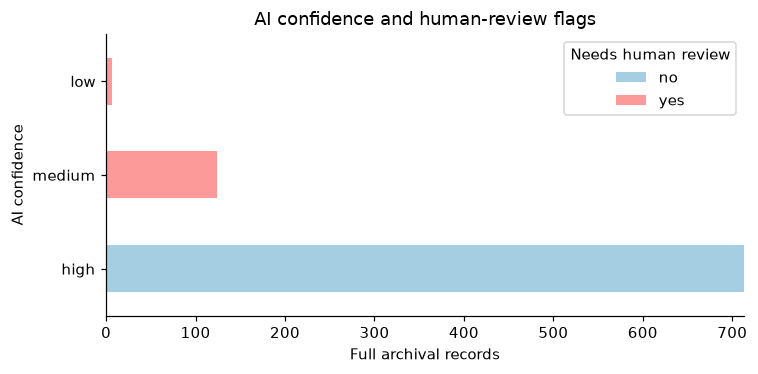

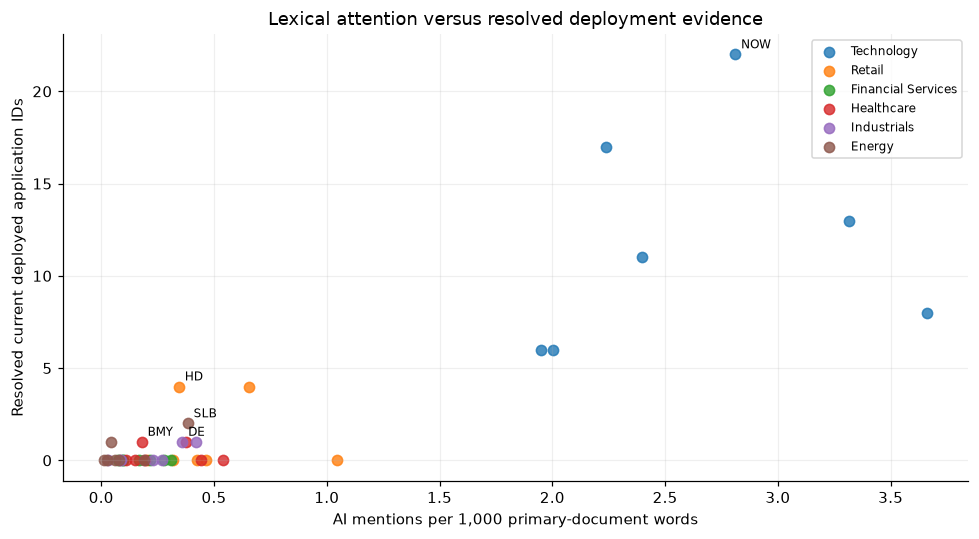

In [11]:
quality=pd.crosstab(full.coding_confidence,full.needs_human_review).reindex(index=['high','medium','low'],columns=['no','yes'],fill_value=0).fillna(0)
fig,ax=plt.subplots(figsize=(7,3.5));quality.plot.barh(stacked=True,ax=ax,color=['#a6cee3','#fb9a99'])
ax.set(title='AI confidence and human-review flags',xlabel='Full archival records',ylabel='AI confidence');ax.legend(title='Needs human review');fig.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(9,5))
for sector,g in metrics.groupby('sector',sort=False):
    ax.scatter(g.ai_mentions_per_1000_words,g.deployed_use_case_count,color=palette[sector],label=short[sector],s=45,alpha=.8)
    for _,r in g.nlargest(1,'deployed_use_case_count').iterrows():
        if r.deployed_use_case_count > 0:ax.annotate(r.ticker,(r.ai_mentions_per_1000_words,r.deployed_use_case_count),xytext=(4,4),textcoords='offset points',fontsize=8)
ax.set(title='Lexical attention versus resolved deployment evidence',xlabel='AI mentions per 1,000 primary-document words',ylabel='Resolved current deployed application IDs')
ax.legend(fontsize=8);ax.grid(alpha=.2);fig.tight_layout();plt.show()

## 6 — Preliminary insights and limitations

The following summaries are computed from the loaded snapshot. They concern disclosed evidence, not independently verified corporate adoption. Sector differences may reflect provider business models, source scope, filing length, and disclosure conventions; these are hypotheses for future validation.

In [12]:
tech = sector_summary.loc['Technology / Software']
other = sector_summary.drop(index='Technology / Software')
na_count=(full.adoption_stage == 'NA').sum()
display(Markdown(f"""- Technology firms have mean lexical density **{tech.mean_mentions_per_1000:.3f}** mentions/1,000 words, versus **{other.mean_mentions_per_1000.min():.3f}–{other.mean_mentions_per_1000.max():.3f}** for the other sector means. Product-provider scope is prominent; this is not an internal-adoption ranking.
- **{metrics.reported_deployment_present.sum()} of {len(metrics)}** selected primary filings contain coded current deployment evidence. **{metrics.deployed_use_case_count.sum()}** resolved deployed application IDs were identified; broad current-use claims often do not identify countable tasks.
- **{na_count}/{len(full)} ({100*na_count/len(full):.1f}%)** archival records are NA; risk/governance without qualifying stage is the largest priority-based group. **{(metrics.stage_eligible_claim_count == 0).sum()}** firms have zero observed eligible claims, with no firm-level Stage 0 or nonadoption inference.
- Human validation remains pending for **all {len(full)} records**, including the **{(full.needs_human_review == 'yes').sum()}** flagged for priority review. No extraction accuracy, classification accuracy or inter-coder reliability estimate exists.
"""))
display(Markdown('Future work: independently code a stratified candidate/nonmatching reference set; adjudicate actor, task identity, pilot and deployment thresholds; evaluate extraction recall separately; examine incorporated reports under an explicitly expanded source scope; and test business-model/period sensitivity. Human-validated topic/word shares, vague maturity scores and causal outcome analysis are deferred.'))

- Technology firms have mean lexical density **2.625** mentions/1,000 words, versus **0.114–0.493** for the other sector means. Product-provider scope is prominent; this is not an internal-adoption ranking.
- **29 of 42** selected primary filings contain coded current deployment evidence. **98** resolved deployed application IDs were identified; broad current-use claims often do not identify countable tasks.
- **568/844 (67.3%)** archival records are NA; risk/governance without qualifying stage is the largest priority-based group. **8** firms have zero observed eligible claims, with no firm-level Stage 0 or nonadoption inference.
- Human validation remains pending for **all 844 records**, including the **131** flagged for priority review. No extraction accuracy, classification accuracy or inter-coder reliability estimate exists.


Future work: independently code a stratified candidate/nonmatching reference set; adjudicate actor, task identity, pilot and deployment thresholds; evaluate extraction recall separately; examine incorporated reports under an explicitly expanded source scope; and test business-model/period sensitivity. Human-validated topic/word shares, vague maturity scores and causal outcome analysis are deferred.